In [1]:
import sys
!{sys.executable} -m pip install fredapi yfinance alpha_vantage


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


In [2]:
from fredapi import Fred
import pandas as pd

fred = Fred(api_key='b29fa8db713c7d9498fc161a88fb77ac')

#UNRATE: unemployment rate
#CPIAUCSL: consumer price index (inflaton)
#FEDFUNDS: effective federal funds rate (interest rates)
#GDPC1: Real Gross Domestic Product
#T10Y2Y: Yield Curve (recession indicator)
#TEDRATE: TED Spread (interbank credit risk)
#VIXLS: CBOE (market fear)
#BAMLH0A0HYM2: Bank of America's US High Yield Index (Credit risk)

indexes = ['UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'GDPC1', 'T10Y2Y', 'TEDRATE', 'VIXCLS', 'BAMLH0A0HYM2']

data = {}
for index in indexes:
    data[index] = fred.get_series(index)

df_macro = pd.DataFrame(data)
df_macro.index.name = 'Date'
df_macro = df_macro.loc['2000-01-01':]

In [3]:
import yfinance as yf

#ticker symbols
# CL=F: crude oil futures
# GC=F: gold futures 
# XLE: energy select sector (correlation with oil)
# XLK: technology select sector
# XLF: financial sector (rate sensistive)
# GSPC: S and P 500 Index
# TNX: 10 year treasuring yield

tickers = ['CL=F', 'GC=F', 'XLE', 'XLK', 'XLF', '^GSPC', '^TNX']
df_sector = yf.download(tickers, start="2000-01-01", interval="1d", auto_adjust=True)['Close']

[*********************100%***********************]  7 of 7 completed


In [4]:
from alpha_vantage.foreignexchange import ForeignExchange 
import time

fe = ForeignExchange(key='DCCXHV23S5TTXJT1', output_format='pandas')

#exchange rates for US dollar against other
currencies = ['EUR', 'KRW', 'CAD']
fx_data = []

for currency in currencies:
    try:
        data, _ = fe.get_currency_exchange_daily(from_symbol='USD', to_symbol=currency)
        
        series = data['4. close'].rename(f'USD_{currency}')
        fx_data.append(series)
        
        # Pause to respect free tier API limits (5 calls per minute)
        time.sleep(3) 
        
    except Exception as e:
        print(f"Error fetching {currency}: {e}")

df_fx = pd.concat(fx_data, axis=1)

In [5]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [6]:
df_main = df_sector.join(df_macro, how='outer').join(df_fx, how='outer')
df_main.sort_index(inplace=True)

# forward fill bc market uses that monthly or weekly number
df_main.fillna(method='ffill', inplace=True)
df_main.dropna(inplace=True)
df_main

/var/folders/n9/hrwgbvx936vf2n8y560vb_lc0000gn/T/ipykernel_22424/2310242047.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_main.fillna(method='ffill', inplace=True)


,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
2025-10-07,61.730000,3976.600098,44.366802,53.582726,142.623672,6714.589844,4.127,4.4,324.245,4.09,24111.83,0.57,0.09,17.24,2.82,0.8577,1415.87,1.3949
2025-10-08,62.549999,4043.300049,44.109001,53.323631,145.124878,6753.720215,4.129,4.4,324.245,4.09,24111.83,0.55,0.09,16.30,2.84,0.8599,1421.34,1.3950
2025-10-09,61.509998,3946.300049,43.509113,53.134293,144.880249,6735.109863,4.148,4.4,324.245,4.09,24111.83,0.54,0.09,16.43,2.95,0.8646,1422.72,1.4018
2025-10-10,58.900002,3975.899902,42.249847,51.978333,138.984192,6552.509766,4.051,4.4,324.245,4.09,24111.83,0.53,0.09,21.66,3.18,0.8604,1429.04,1.4004
2025-10-13,59.490002,4108.600098,42.824944,52.476593,142.369064,6654.720215,4.051,4.4,324.245,4.09,24111.83,0.53,0.09,19.03,3.18,0.8642,1426.28,1.4035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,62.330002,4882.899902,53.750000,52.200001,139.479996,6843.220215,4.052,4.3,326.588,3.64,24111.83,0.62,0.09,20.29,2.94,0.8434,1444.45,1.3635
2026-02-18,65.190002,4986.500000,54.779999,52.590000,140.910004,6881.310059,4.079,4.3,326.588,3.64,24111.83,0.62,0.09,19.62,2.86,0.8485,1442.44,1.3695
2026-02-19,66.430000,4975.899902,55.180000,52.150002,140.210007,6861.890137,4.075,4.3,326.588,3.64,24111.83,0.61,0.09,20.23,2.88,0.8493,1449.44,1.3679
2026-02-20,66.389999,5059.299805,54.880001,52.490002,140.880005,6909.509766,4.086,4.3,326.588,3.64,24111.83,0.60,0.09,19.09,2.86,0.8487,1446.00,1.3678


In [7]:
df_main.drop(columns=['GDPC1'], inplace=True)
df_main.drop(columns=['TEDRATE'], inplace=True)

In [8]:
# need to make sure PCMCI picks up on actual dependencies, and not just a general growth

df_transform = pd.DataFrame(index=df_main.index)

#1. rates and spreads: these variables are percentages or indices so we care more about the change 
rate_vars = ['UNRATE', 'FEDFUNDS', 'T10Y2Y', 'BAMLH0A0HYM2', 'VIXCLS', 'TEDRATE']

#2. asset prices: grows exponentially and would cause heteroscedasticity so use log 
price_vars = [col for col in df_main.columns if col not in rate_vars]

for col in df_main.columns:
    if col in rate_vars:
        # simple difference
        df_transform[col] = df_main[col].diff()
    else:
        #log of returns (ln(price today / price yesterday))
        df_transform[col] = np.log(df_main[col] / df_main[col].shift(1))

df_transform.dropna(inplace=True)

In [9]:
# Install Tigramite and dependencies
!pip install Cython
!pip install tigramite
!pip install pandas numpy matplotlib seaborn
!pip install tigramite matplotlib pandas numpy

In [10]:
df_transform.head()

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,T10Y2Y,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
2025-10-08,0.013196,0.016634,-0.005828,-0.004847,0.017385,0.005811,0.000485,0.0,0.0,0.0,-0.02,-0.94,0.02,0.002562,0.003856,0.000072
2025-10-09,-0.016766,-0.024283,-0.013693,-0.003557,-0.001687,-0.002759,0.004591,0.0,0.0,0.0,-0.01,0.13,0.11,0.005451,0.000970,0.004863
2025-10-10,-0.043359,0.007473,-0.029370,-0.021996,-0.041547,-0.027486,-0.023662,0.0,0.0,0.0,-0.01,5.23,0.23,-0.004870,0.004432,-0.000999
2025-10-13,0.009967,0.032831,0.013520,0.009540,0.024063,0.015478,0.000000,0.0,0.0,0.0,0.00,-2.63,0.00,0.004407,-0.001933,0.002211
2025-10-14,-0.013369,0.007299,-0.000116,0.010954,-0.012917,-0.001566,-0.007185,0.0,0.0,0.0,0.02,1.78,-0.07,-0.003129,0.001625,0.000499


In [11]:
import sys

# 1. Install specifically for the active kernel
%pip install tigramite

# 2. Add the current environment's path to sys.path manually (emergency bypass)
if sys.prefix not in sys.path:
    sys.path.append(f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages")

# 3. Test the import immediately
try:
    import tigramite
    print("Success! Tigramite is now accessible.")
except ImportError:
    print("Still failing. See the 'Nuclear Option' below.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Success! Tigramite is now accessible.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tigramite
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr # Correct import for v5.0+
from tigramite import plotting as tp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# SETUP & DATA PREP

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp


data_source = df_transform

# standardize
scaler = StandardScaler()
values_scaled = scaler.fit_transform(data_source.values)
var_names = data_source.columns.tolist()

# chronological train/test split (80/20)
split_idx = int(len(values_scaled) * 0.8)
train_values = values_scaled[:split_idx]
test_values = values_scaled[split_idx:]

# Tigramite objects
train_dataframe = dp.DataFrame(train_values, datatime=np.arange(len(train_values)), var_names=var_names)
test_dataframe = dp.DataFrame(test_values, datatime=np.arange(len(test_values)), var_names=var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_dataframe, cond_ind_test=parcorr, verbosity=0)

print(f"Data prepped variables: {var_names}")
print(f"Training on {len(train_values)} days, testing on {len(test_values)} days")

Data prepped variables: ['CL=F', 'GC=F', 'XLE', 'XLF', 'XLK', '^GSPC', '^TNX', 'UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'T10Y2Y', 'VIXCLS', 'BAMLH0A0HYM2', 'USD_EUR', 'USD_KRW', 'USD_CAD']
Training on 81 days, testing on 21 days


In [17]:
var_names

['CL=F',
 'GC=F',
 'XLE',
 'XLF',
 'XLK',
 '^GSPC',
 '^TNX',
 'UNRATE',
 'CPIAUCSL',
 'FEDFUNDS',
 'T10Y2Y',
 'VIXCLS',
 'BAMLH0A0HYM2',
 'USD_EUR',
 'USD_KRW',
 'USD_CAD']

# CAUSAL DISCOVERY

--- Running PCMCI Causal Discovery for Target: XLE ---

 FULL VARIABLE CHART (Target: XLE)
Alpha Threshold: 0.05
Index | Variable     | Lag  | Strength (MCI)  | P-Value    | Kept by PCMCI?
--------------------------------------------------------------------------------
3     | XLF          | 1    |    -0.3832      | 0.00149    | YES
6     | ^TNX         | 5    |    -0.3059      | 0.01250    | YES
12    | BAMLH0A0HYM2 | 5    |     0.3036      | 0.01396    | YES
4     | XLK          | 2    |     0.2775      | 0.02300    | YES
7     | UNRATE       | 2    |    -0.2674      | 0.02994    | YES
12    | BAMLH0A0HYM2 | 3    |     0.2616      | 0.03384    | YES
0     | CL=F         | 1    |    -0.2476      | 0.04850    | YES
15    | USD_CAD      | 3    |     0.2319      | 0.06102    | NO
11    | VIXCLS       | 1    |    -0.2316      | 0.05930    | NO
13    | USD_EUR      | 4    |     0.2160      | 0.08402    | NO
7     | UNRATE       | 4    |     0.2028      | 0.10513    | NO
6     | ^TNX       

<Figure size 1000x1000 with 0 Axes>

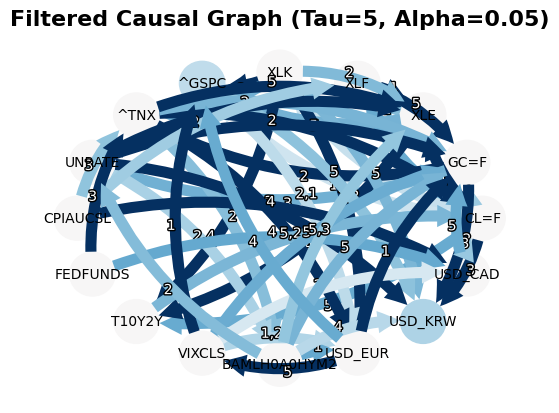

<Figure size 1000x1000 with 0 Axes>

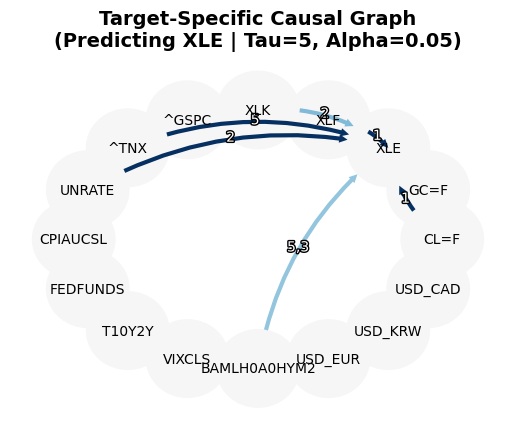

In [26]:
# --- HYPERPARAMETER CONTROL PANEL ---
TAU_MIN = 1       
TAU_MAX = 5       # maximum lookback window
ALPHA = 0.05      # significance threshold 
TARGET_VAR = 2    # index of variable to predict


target_name = var_names[TARGET_VAR]
print(f"--- Running PCMCI Causal Discovery for Target: {target_name} ---")

# run PCMCI
results = pcmci.run_pcmci(tau_min=TAU_MIN, tau_max=TAU_MAX, pc_alpha=ALPHA)

# extract matrices
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']

all_tested_relations = []

# scan every variable at every lag
for var_j in range(len(var_names)):
    for lag in range(TAU_MIN, TAU_MAX + 1): 
        strength = val_matrix[var_j, TARGET_VAR, lag]
        p_val = p_matrix[var_j, TARGET_VAR, lag]
        
        # Check if algorithm accepted variable based on alpha
        passed_test = "YES" if p_val <= ALPHA else "NO"
        
        all_tested_relations.append({
            "Variable": var_names[var_j],
            "Index": var_j,
            "Lag": lag,
            "Strength": strength,
            "P-Value": p_val,
            "Passed": passed_test
        })

# sort by strongest relations first (Absolute Strength)
all_tested_relations.sort(key=lambda x: abs(x["Strength"]), reverse=True)

# print all relations
print(f"\n FULL VARIABLE CHART (Target: {target_name})")
print(f"Alpha Threshold: {ALPHA}")
print(f"{'Index':<5} | {'Variable':<12} | {'Lag':<4} | {'Strength (MCI)':<15} | {'P-Value':<10} | {'Kept by PCMCI?'}")
print("-" * 80)

for p in all_tested_relations:
    # highlight variables that passed
    if p["Passed"] == "YES":
        print(f"{p['Index']:<5} | {p['Variable']:<12} | {p['Lag']:<4} | {p['Strength']:>10.4f}      | {p['P-Value']:<10.5f} | {p['Passed']}")
    else:
        #dim relations that failed 
        print(f"{p['Index']:<5} | {p['Variable']:<12} | {p['Lag']:<4} | {p['Strength']:>10.4f}      | {p['P-Value']:<10.5f} | {p['Passed']}")

filtered_graph = np.copy(graph)
filtered_val_matrix = np.copy(val_matrix)

# Blank out ANY edge in the entire system that failed the alpha test
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX + 1):
            if p_matrix[i, j, tau] > ALPHA:
                filtered_graph[i, j, tau] = ""            # Remove the arrow
                filtered_val_matrix[i, j, tau] = 0.0      # Remove the color/strength

# Visualize the PRUNED Graph
plt.figure(figsize=(10, 10))
tp.plot_graph(
    val_matrix=filtered_val_matrix,
    graph=filtered_graph,
    var_names=var_names,
    vmin_edges=0.0,      # Set to 0 so we don't accidentally hide weak but significant links
    show_colorbar=False,
    label_fontsize=12
)
plt.title(f"Filtered Causal Graph (Tau={TAU_MAX}, Alpha={ALPHA})", fontsize=16, fontweight='bold')
plt.show()

filtered_graph = np.empty_like(graph)
filtered_graph.fill("") 
filtered_val_matrix = np.zeros_like(val_matrix) 

# Rebuild ONLY the edges that point to the TARGET and passed the test
for p in all_tested_relations:
    if p["Passed"] == "YES":
        i = p["Index"]
        tau = p["Lag"]
        
        # Copy the specific arrow from the original results to our clean slate
        filtered_graph[i, TARGET_VAR, tau] = graph[i, TARGET_VAR, tau]
        filtered_val_matrix[i, TARGET_VAR, tau] = val_matrix[i, TARGET_VAR, tau]

# 5. Visualize the Clean Graph
plt.figure(figsize=(10, 10))
tp.plot_graph(
    val_matrix=filtered_val_matrix,
    graph=filtered_graph,
    var_names=var_names,
    vmin_edges=0.0,      # Show everything we manually approved
    show_colorbar=False,
    label_fontsize=12,
    node_size=0.6,
    arrow_linewidth=3.0
)
plt.title(f"Target-Specific Causal Graph\n(Predicting {target_name} | Tau={TAU_MAX}, Alpha={ALPHA})", fontsize=14, fontweight='bold')
plt.show()

In [15]:
# LINEAR REGRESSION & FEATURE SELECTION

# --- FEATURE SELECTION PANEL ---
# manually define the features you want to include in your regression.
# Format: (Variable_Index, Lag_Amount)
# You can get the Index from the var_names list printed in Block 1.

MANUAL_PREDICTORS = [
    # (Index, Lag)  # Comment (Name)
    (3, 2),         # GC=F (Gold) at Lag 2
    #(1, 5),        # Example: ^TNX at Lag 5 (Uncomment to test adding this)
    #(2, 5),        # Example: T10Y2Y at Lag 5 (Uncomment to test adding this)
]
# ----------------------------------

# ensure alignment by cutting off the max lag we might test
GLOBAL_CUTOFF = 10 
target_idx = TARGET_VAR 

def train_and_evaluate(train_data, test_data, features):
    # Fallback if list is empty
    if not features:
        print("No predictors selected. Using Autoregression (Target Lag 1).")
        features = [(target_idx, 1)]
        
    def build_xy(data):
        y = data[GLOBAL_CUTOFF:, target_idx]
        X_cols = []
        for (var_idx, lag) in features:
            col = np.roll(data[:, var_idx], shift=lag)[GLOBAL_CUTOFF:]
            X_cols.append(col)
        return np.column_stack(X_cols), y

    # Prepare Data Matrices
    X_train, y_train = build_xy(train_data)
    X_test, y_test   = build_xy(test_data)
    
    # Train & Test
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    
    return mse, model

# Run Evaluation
mse_result, trained_model = train_and_evaluate(train_values, test_values, MANUAL_PREDICTORS)

# Print Summary
print("\n--- REGRESSION RESULTS ---")
print("Features Used:")
for (idx, lag) in MANUAL_PREDICTORS:
    print(f"  -> {var_names[idx]} (Lag {lag})")
    
if not MANUAL_PREDICTORS:
    print(f"  -> {var_names[target_idx]} (Lag 1) [Fallback]")

print("-" * 30)
print(f"Test Set MSE: {mse_result:.5f}")


--- 📊 REGRESSION RESULTS ---
Features Used:
  -> XLF (Lag 2)
------------------------------
🎯 Test Set MSE: 0.99456


Starting Grid Search for Target Variable: 'XLE'
Testing 5 Lags and 5 Alphas (25 total models)...

   [Done] Tau: 1 | Alpha: 0.01 | Predictors: 1  | MSE: 1.76973
   [Done] Tau: 1 | Alpha: 0.05 | Predictors: 1  | MSE: 1.76973
   [Done] Tau: 1 | Alpha: 0.1  | Predictors: 1  | MSE: 1.76973
   [Done] Tau: 1 | Alpha: 0.15 | Predictors: 1  | MSE: 1.76973
   [Done] Tau: 1 | Alpha: 0.2  | Predictors: 2  | MSE: 1.82084
   [Done] Tau: 2 | Alpha: 0.01 | Predictors: 4  | MSE: 1.79314
   [Done] Tau: 2 | Alpha: 0.05 | Predictors: 5  | MSE: 1.89198
   [Done] Tau: 2 | Alpha: 0.1  | Predictors: 4  | MSE: 1.81751
   [Done] Tau: 2 | Alpha: 0.15 | Predictors: 5  | MSE: 1.89198
   [Done] Tau: 2 | Alpha: 0.2  | Predictors: 5  | MSE: 1.89198
   [Done] Tau: 3 | Alpha: 0.01 | Predictors: 5  | MSE: 1.60988
   [Done] Tau: 3 | Alpha: 0.05 | Predictors: 7  | MSE: 1.45884
   [Done] Tau: 3 | Alpha: 0.1  | Predictors: 5  | MSE: 1.89198
   [Done] Tau: 3 | Alpha: 0.15 | Predictors: 4  | MSE: 1.63716
   [Done] Tau: 3 | A

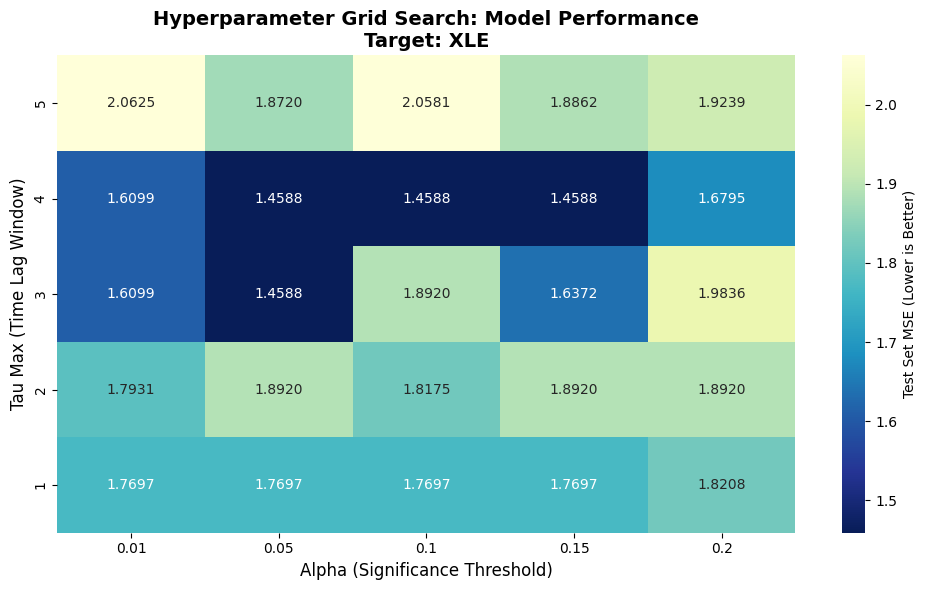

In [27]:
# GRID SEARCH: HYPERPARAMETER OPTIMIZATION & HEATMAP EMPIRICALLY

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

data_source = df_transform

# Standardize
scaler = StandardScaler()
values_scaled = scaler.fit_transform(data_source.values)
var_names = data_source.columns.tolist()

# Chronological Train/Test Split (80/20)
split_idx = int(len(values_scaled) * 0.8)
train_values = values_scaled[:split_idx]
test_values = values_scaled[split_idx:]

train_dataframe = dp.DataFrame(train_values, datatime=np.arange(len(train_values)), var_names=var_names)
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_dataframe, cond_ind_test=parcorr, verbosity=0)

# --- GRID SEARCH SETTINGS ---
TARGET_VAR = 2  # Index variable to predict
tau_max_list = [1, 2, 3, 4, 5]                  # different Time Lags to test
alpha_list = [0.01, 0.05, 0.10, 0.15, 0.20]     # different Alphas to test

# To ensure fair testing, ALL models must drop the same number of initial rows.
# We use the absolute maximum lag being tested as the universal cutoff.
GLOBAL_CUTOFF = max(tau_max_list) 

results_log = []

print(f"Starting Grid Search for Target Variable: '{var_names[TARGET_VAR]}'")
print(f"Testing {len(tau_max_list)} Lags and {len(alpha_list)} Alphas ({len(tau_max_list) * len(alpha_list)} total models)...\n")

# EXPERIMENT LOOP 
for tau in tau_max_list:
    for alpha in alpha_list:
        
        # run causal discovery
        # always set tau_min=1 to enforce strictly predictive forecasting
        pcmci_res = pcmci.run_pcmci(tau_min=1, tau_max=tau, pc_alpha=alpha)
        
        graph = pcmci_res['graph']
        parents = []
        
        # extract discovered parents
        for var_j in range(len(var_names)):
            for lag in range(1, tau + 1):
                if graph[var_j, TARGET_VAR, lag] != "":
                    parents.append((var_j, lag))
                    
        # fallback if no parents are found (simple autoregression)
        if not parents:
            parents.append((TARGET_VAR, 1))
            
        # build regression matrices (X, y)
        def build_xy(data):
            y = data[GLOBAL_CUTOFF:, TARGET_VAR]
            X_cols = []
            for (var_idx, lag) in parents:
                col = np.roll(data[:, var_idx], shift=lag)[GLOBAL_CUTOFF:]
                X_cols.append(col)
            return np.column_stack(X_cols), y

        X_train, y_train = build_xy(train_values)
        X_test, y_test   = build_xy(test_values)
        
        # train and evaluate
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        
        # store results
        results_log.append({
            'Tau Max': tau,
            'Alpha': alpha,
            'MSE': mse,
            'Num Predictors': len(parents)
        })
        print(f" Tau: {tau} | Alpha: {alpha:<4} | Predictors: {len(parents):<2} | MSE: {mse:.5f}")

# --- PROCESS RESULTS ---
results_df = pd.DataFrame(results_log)

# find the best combination
best_run = results_df.loc[results_df['MSE'].idxmin()]
print("\n BEST MODEL FOUND:")
print(f"Tau Max: {int(best_run['Tau Max'])}")
print(f"Alpha:   {best_run['Alpha']}")
print(f"Features:{int(best_run['Num Predictors'])}")
print(f"MSE:     {best_run['MSE']:.5f}")

# --- PERFORMANCE HEATMAP ---
# create pivot table for heatmap
heatmap_data = results_df.pivot(index='Tau Max', columns='Alpha', values='MSE')

plt.figure(figsize=(10, 6))
# colormap where lower MSE is blue-er and higher MSE is red-er
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu_r", cbar_kws={'label': 'Test Set MSE (Lower is Better)'})

plt.title(f"Hyperparameter Grid Search: Model Performance\nTarget: {var_names[TARGET_VAR]}", fontsize=14, fontweight='bold')
plt.xlabel("Alpha (Significance Threshold)", fontsize=12)
plt.ylabel("Tau Max (Time Lag Window)", fontsize=12)
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()